In [1]:
import os
import copy
import pickle
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import similaritymeasures as sm
import matplotlib.patches as patches

from bisect import bisect
from tqdm.notebook import tqdm
from scipy.stats import spearmanr
from matplotlib.gridspec import GridSpec
from processing_TowerCoordinates import *
from matplotlib.ticker import MaxNLocator
from processing_session_trajectory import *

plt.style.use('paper.mplstyle')


In [2]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.


path_to_data_folder = '/home/david/MyLocalData/Lesions'

# Analysing the entire group of mice
mice_to_analyse = ['MOUB6JRj753','MOUB6JRj755','MOUB6JRj756','MOU5289','MOU5291','MOU5413','MOU5415','MOU5471','MOU5496','MOU5498']

# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes = [0,32]


All mice folders are present in data folder.
 10 mice will be analysed



In [3]:
LESION_ANIMALS: list[str] = ['MOUB6JRj755','MOU5289','MOU5415','MOU5471','MOU5496']
SHAM_ANIMALS: list[str] = ['MOUB6JRj753','MOUB6JRj756','MOU5291','MOU5413','MOU5498']

groups = {
    "Lesion": LESION_ANIMALS,
    "Sham": SHAM_ANIMALS
}


## Global parameters and functions

In [4]:
# Arena parameters

arena_coordinates_cm=[[2.5, 91.7], [90.3, 91.7], [90.3, 2.7], [2.5, 2.7]]

border_zone = [
    [(3, 3), (10, 3), (10, 90), (3, 90)],   # left
    [(3, 3), (3, 9.5), (92, 9.5), (92, 3)], # down
    [(84, 3), (92, 3), (92, 90), (84, 90)], # right
    [(3, 83), (3, 90), (92, 90), (92, 83)]  # up
]

trapeze_width = 30


In [5]:
# Global functions 

def cm2inch(value):
    return value / 2.54

def get_day_and_period(session_idx):
    day = session_idx // 2 + 1
    period = 'AM' if session_idx % 2 == 0 else 'PM'
    return day, period

def finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index):
    sessions_to_process = sorted([
        name for name in os.listdir(folder_path_mouse_to_process)
        if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
        and name.startswith('MOU')
    ])

    session_traj_df, session_turns_df, session_param_df = load_data(
        folder_path_mouse_to_process,
        sessions_to_process[session_index]
    )

    rewarded_direction_degrees = session_param_df["potentialRewardedDirections"][0]

    if session_param_df["allowRewardDelivery"][0]:
        if rewarded_direction_degrees == '[270]':
            rewarded_direction = 'CW'
        elif rewarded_direction_degrees == '[90]':
            rewarded_direction = 'CCW'
        elif rewarded_direction_degrees == '[90, 270]':
            rewarded_direction = 'both'
        else:
            print('ERROR: Unexpected rewarded direction value:', rewarded_direction_degrees)
            return None
    else:
        rewarded_direction = 'X'

    return rewarded_direction

def finding_mouse_timeout(folder_path_mouse_to_process, session_index):
    sessions_to_process = sorted([
        name for name in os.listdir(folder_path_mouse_to_process)
        if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
        and name.startswith('MOU')
    ])

    try:
        session_traj_df, session_turns_df, session_param_df = load_data(
            folder_path_mouse_to_process,
            sessions_to_process[session_index]
        )
    except Exception:
        return None

    if session_param_df is None:
        return None

    if 'Timeout' not in session_param_df.columns:
        return None

    timeout_value = session_param_df['Timeout'].iloc[0]

    if pd.isna(timeout_value):
        return None

    try:
        if isinstance(timeout_value, str):
            timeout_value = timeout_value.strip().replace('[', '').replace(']', '')
            if timeout_value == '':
                return None
            timeout_value = float(timeout_value)
        else:
            timeout_value = float(timeout_value)
    except Exception:
        return None

    if timeout_value.is_integer():
        timeout_value = int(timeout_value)

    return timeout_value

def add_timeout_background(ax, all_sessions, folder_path_reference_mouse, index_offset=0, session_threshold=21, alpha=0.18):
    timeout_colors = {
        0: 'lightgreen',
        5: '#ffe699',
        15: '#f4a3a3'
    }

    for session in all_sessions:
        if session < session_threshold:
            continue

        zero_based_session_index = session - 1

        timeout_value = finding_mouse_timeout(
            folder_path_reference_mouse,
            zero_based_session_index
        )

        if timeout_value not in timeout_colors:
            continue

        ax.axvspan(
            session + index_offset - 0.49,
            session + index_offset + 0.49,
            ymin=0,
            ymax=1,
            color=timeout_colors[timeout_value],
            alpha=alpha,
            zorder=-2,
            lw=0
        )

def filter_qts(qts):
    """
    Filtre les QTs comme dans Figure08:
    - enlève les QTs avec plus d'un trapeze switch
    - enlève les QTs dont la distance > 30 cm
    """
    filtered_qts = []

    for qt in qts:
        if qt[3]['num_trapezeswitch'] != 1:
            continue
        if qt[4]['epoch_distance'] > 30:
            continue
        filtered_qts.append(qt)

    return filtered_qts



In [6]:
# Plot functions

def get_group_summary(ax, mice_list, mouse_metric_persession, color, show_individual_mice, index_offset):
        all_session_indices = set()
        values_per_session = {}

        for mouse in mice_list:
            if mouse not in mouse_metric_persession:
                print(f"Mouse {mouse} not found in data. Skipping.")
                continue

            sessions = mouse_metric_persession[mouse]
            session_indices = [session[0] for session in sessions]
            values = [session[1] for session in sessions]

            if sum(np.isnan(x) for x in values) > 0:
                session_indices_array = np.array(session_indices)
                values_array = np.array(values)
                mask = ~np.isnan(values_array)
                session_indices = session_indices_array[mask]
                values = values_array[mask]

            if show_individual_mice and len(session_indices) > 0:
                ax.plot(
                    np.array(session_indices) + index_offset,
                    values,
                    marker='o',
                    linewidth=0.7,
                    markersize=1,
                    alpha=0.25,
                    color=color,
                    zorder=1
                )

            all_session_indices.update(session_indices)
            for session, value in sessions:
                if session not in values_per_session:
                    values_per_session[session] = []
                values_per_session[session].append(value)

        sorted_sessions = sorted(all_session_indices)

        median_values = []
        lower_quartile = []
        upper_quartile = []

        for session in sorted_sessions:
            session_values = values_per_session[session]
            median_values.append(np.nanmedian(session_values))
            lower_quartile.append(np.nanpercentile(session_values, 25))
            upper_quartile.append(np.nanpercentile(session_values, 75))

        return (
            np.array(sorted_sessions),
            np.array(median_values),
            np.array(lower_quartile),
            np.array(upper_quartile)
        )

def plot_learning_curves_two_groups(
    mouse_metric_persession,
    ax,
    group1_mice,
    group2_mice,
    group1_label='Sham',
    group2_label='Lesion',
    group1_color='black',
    group2_color='deeppink',
    show_individual_mice=True,
    ylabel='',
    show_xlabel=True,
    tick_interval=1,
    index_offset=0,
    xlim=[None, None],
    ylim=None,
    show_fam=False,
    show_legend=True,
    legend_loc=(0.05, 0.9)
):

    s1, med1, q1_low, q1_high = get_group_summary(ax, group1_mice, mouse_metric_persession, group1_color, show_individual_mice, index_offset)
    s2, med2, q2_low, q2_high = get_group_summary(ax, group2_mice, mouse_metric_persession, group2_color, show_individual_mice, index_offset)

    if len(s1) > 0:
        ax.plot(s1 + index_offset, med1, color=group1_color, linewidth=2, zorder=10, alpha = 1,
                label=f'{group1_label} (n={len(group1_mice)})')
        ax.fill_between(s1 + index_offset,
                        q1_low,
                        q1_high,
                        color=group1_color,
                        alpha=0.2,
                        linewidth=0,
                        edgecolor='none',
                        antialiased=False
                    )

    if len(s2) > 0:
        ax.plot(s2 + index_offset, med2, color=group2_color, linewidth=2,zorder=10, alpha = 1,
                label=f'{group2_label} (n={len(group2_mice)})')
        ax.fill_between(s2 + index_offset,
                        q2_low,
                        q2_high,
                        color=group2_color,
                        alpha=0.2,
                        linewidth=0,
                        edgecolor='none',
                        antialiased=False
                    )

    if show_xlabel:
        ax.set_xlabel('Session Number', fontsize=7)

    ax.set_ylabel(ylabel, fontsize=7)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    all_sessions = sorted(set(list(s1) + list(s2)))
    if len(all_sessions) > 0:
        max_index = max(all_sessions)
        ax.set_xticks(range(1 + index_offset, max_index + 1 + index_offset, tick_interval))

        # Use first mouse as reference to determine session parameters
        first_mouse = list(mouse_metric_persession.keys())[0]
        folder_path_first_mouse = os.path.join(path_to_data_folder, first_mouse)

        # Background color for timeout in depleting protocol only (from session 21)
        add_timeout_background(
            ax=ax,
            all_sessions=all_sessions,
            folder_path_reference_mouse=folder_path_first_mouse,
            index_offset=index_offset,
            session_threshold=21,
            alpha=0.18
        )

        for session in all_sessions:

            zero_based_session_index = session - 1

            rewarded_direction = finding_mouse_rewarded_direction(
                folder_path_first_mouse,
                zero_based_session_index
            )

            if rewarded_direction == 'X':
                band_color = "orange"

            elif rewarded_direction == "both":
                band_color = "#a875bc"

            elif rewarded_direction == "CW" :
                band_color = "blue"

            elif rewarded_direction == "CCW":
                band_color = "red"

            ax.axvspan(
                session + index_offset - 0.49,
                session + index_offset + 0.49,
                ymin=0.979,
                ymax=0.998,
                color=band_color,
                zorder=3,
                clip_on=False
            )

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ylimits = ax.get_ylim()
    rectangle_height = abs(ylimits[1] - ylimits[0])
    rect = patches.Rectangle((0.5, ylimits[0]), 2, rectangle_height, color='moccasin', alpha=1, lw=0, zorder=0)
    ax.add_patch(rect)

    if show_fam:
        ax.text(1.5, ylimits[1], "Fam.", fontsize=6, ha='center', va='bottom',
                fontweight='normal', color='orange', alpha=0.6, zorder=1000)

    if show_legend:
        ax.legend(frameon=False, loc=legend_loc)


In [7]:
# Pickle functions 

def get_pickle_jar_path(folder_path_mouse_to_process, session_to_process):
    session_folder = os.path.join(folder_path_mouse_to_process, session_to_process)
    pickle_jar_path = os.path.join(session_folder, "pickle_jar")
    os.makedirs(pickle_jar_path, exist_ok=True)
    return pickle_jar_path

def frechet_pickles_exist(pickle_jar_path, pickle_names):
    return all(
        os.path.exists(os.path.join(pickle_jar_path, filename))
        for filename in pickle_names.values()
    )

def save_frechet_pickles(pickle_jar_path, frechet_results,pickle_names):
    for key, value in frechet_results.items():
        filepath = os.path.join(pickle_jar_path, pickle_names[key])
        with open(filepath, "wb") as f:
            pickle.dump(value, f)

def load_frechet_pickles(pickle_jar_path, pickle_names):
    frechet_results = {}
    for key, filename in pickle_names.items():
        filepath = os.path.join(pickle_jar_path, filename)
        with open(filepath, "rb") as f:
            frechet_results[key] = pickle.load(f)
    return frechet_results


### Total distance and average speed
Data extraction

In [8]:
total_distance_m = {mouse: [] for mouse in mice_to_analyse}
average_speeds = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:

    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, mouse)
    
    sessions_to_analyse = sorted([
        name for name in os.listdir(folder_path_mouse_to_analyse)
        if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
        and name.startswith('MOU')
    ])
    
    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    for sessionindex, session_to_analyse in enumerate(sessions_to_analyse):
        
        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            output_pickle_filename
        )
        
        if not os.path.exists(output_pickle_filepath):
            total_distance_m[mouse].append([sessionindex + 1, np.nan])
            average_speeds[mouse].append([sessionindex + 1, np.nan])
            continue

        # Charger le pickle
        with open(output_pickle_filepath, "rb") as f:
            data = pickle.load(f)

        distances = data["distances"]
        total_distance = np.sum(distances)/100
        average_speed = data["average_speed"]

        total_distance_m[mouse].append([sessionindex + 1, total_distance])
        average_speeds[mouse].append([sessionindex + 1, average_speed])


Plot

/tmp/ipykernel_8476/3435939781.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


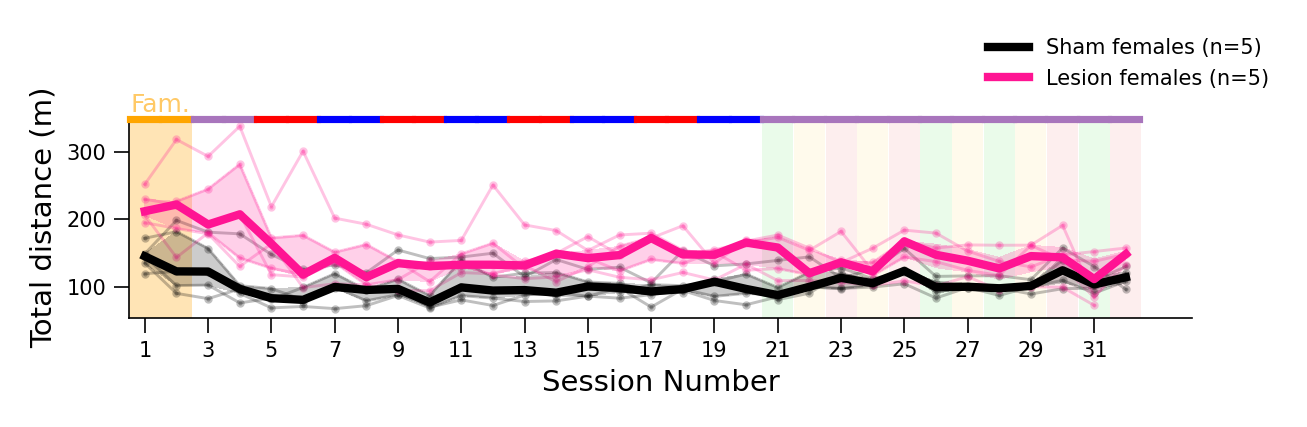

In [9]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(15)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1, hspace=0.45)

row1 = gs[4].subgridspec(1, 1)
ax_1 = plt.subplot(row1[0, 0])

plot_learning_curves_two_groups(
    mouse_metric_persession=total_distance_m,
    ax=ax_1,
    group1_mice=SHAM_ANIMALS,
    group2_mice=LESION_ANIMALS,
    group1_label='Sham females',
    group2_label='Lesion females',
    group1_color='black',
    group2_color='deeppink',
    ylabel='Total distance (m)',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.8, 1.1)
)

fig.tight_layout()
plt.subplots_adjust(left=0.15)
plt.show()


/tmp/ipykernel_8476/2730404078.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


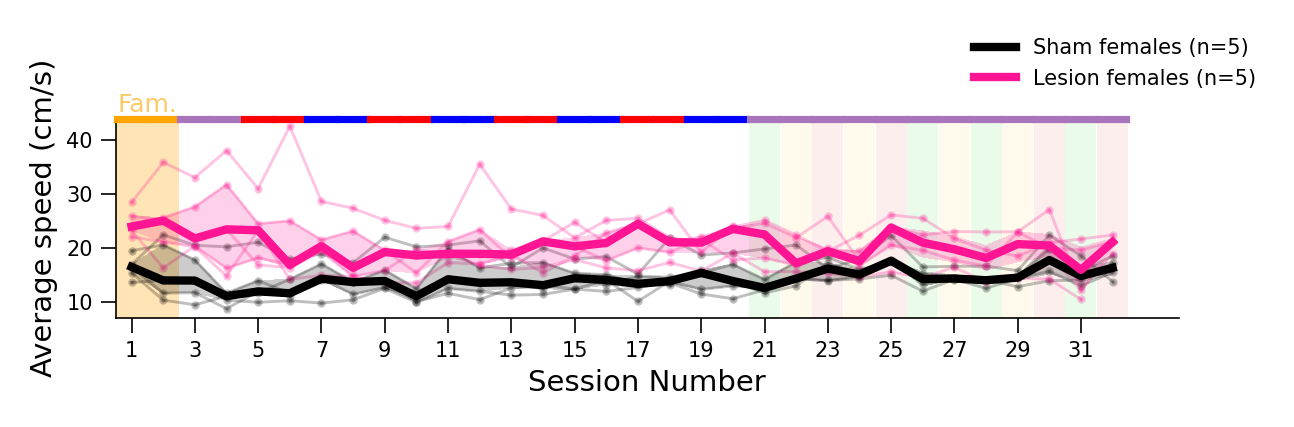

In [10]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(15)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1, hspace=0.45)

row1 = gs[4].subgridspec(1, 1)
ax_1 = plt.subplot(row1[0, 0])

plot_learning_curves_two_groups(
    mouse_metric_persession=average_speeds,
    ax=ax_1,
    group1_mice=SHAM_ANIMALS,
    group2_mice=LESION_ANIMALS,
    group1_label='Sham females',
    group2_label='Lesion females',
    group1_color='black',
    group2_color='deeppink',
    ylabel='Average speed (cm/s)',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.8, 1.1)
)

fig.tight_layout()
plt.subplots_adjust(left=0.15)
plt.show()

### Time spent in trapezes vs border
Function(s)

In [11]:
def calculate_time_in_zones(folder_path_mouse_to_analyse, session_to_analyse, border_zone, trapeze_width, time_start=None, time_end=None):
    
    """Calculate total time spent in border / trapeze / interior zones during a session."""

    pickle_file_path = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, session_to_analyse + '_basic_processing_output.pickle')
    
    towers_coordinates = get_trapeze_and_tower_data(folder_path_mouse_to_analyse, session_to_analyse)[1]
    
    with open(pickle_file_path, 'rb') as f:
        session_data = pickle.load(f)
    
    smoothed_xpositions_cm = session_data['positions'][0]
    smoothed_ypositions_cm = session_data['positions'][1]
    times_videoFrames = session_data['timeofframes']

    all_trapezes_coordinates_cm = generate_trapeze_and_tower_coordinates(towers_coordinates, trapeze_width)[0]

    if time_start is None:
        time_start = times_videoFrames[0]
    if time_end is None:
        time_end = times_videoFrames[-1]

    start_idx = np.searchsorted(times_videoFrames, time_start)
    end_idx = np.searchsorted(times_videoFrames, time_end)

    selected_xpositions = smoothed_xpositions_cm[start_idx:end_idx]
    selected_ypositions = smoothed_ypositions_cm[start_idx:end_idx]
    selected_time = times_videoFrames[start_idx:end_idx]

    border_polygons = [
        mpath.Path(border_zone[0]),
        mpath.Path(border_zone[1]),
        mpath.Path(border_zone[2]),
        mpath.Path(border_zone[3])
    ]
    
    trapeze_polygons = []
    for tower, trapezes in all_trapezes_coordinates_cm.items():
        for trapeze, coords in trapezes.items():
            trapeze_polygons.append(mpath.Path(coords))
    
    inner_setup_size = (10, 9.5, 84, 83)
    interior_polygon = mpath.Path([
        (inner_setup_size[0], inner_setup_size[1]),
        (inner_setup_size[0], inner_setup_size[3]),
        (inner_setup_size[2], inner_setup_size[3]),
        (inner_setup_size[2], inner_setup_size[1])
    ])
    
    time_in_border = 0
    time_in_trapeze = 0
    time_in_interior = 0
  
    for i in range(len(selected_xpositions) - 1):
        point_start = np.array([selected_xpositions[i], selected_ypositions[i]])
        dt = selected_time[i+1] - selected_time[i]

        if any(polygon.contains_point(point_start) for polygon in border_polygons):
            time_in_border += dt
        elif any(polygon.contains_point(point_start) for polygon in trapeze_polygons):
            time_in_trapeze += dt
        elif interior_polygon.contains_point(point_start):
            time_in_interior += dt

    time_spent_in_zones = {
        'border': round(time_in_border, 2),
        'trapeze': round(time_in_trapeze, 2),
        'interior': round(time_in_interior, 2)
    }

    return time_spent_in_zones


Data extraction

In [12]:
# Choosing start and end times (s) of chunks of trajectory
time_start_start = 15
time_end_start = 195
time_start_end = 540
time_end_end = 720

mouse_timediff_trapezevsborder = {mouse: [] for mouse in mice_to_analyse}
mouse_timediff_trapezevsborder_start = {mouse: [] for mouse in mice_to_analyse}
mouse_timediff_trapezevsborder_end = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:

    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, mouse)
    
    sessions_to_analyse = sorted([
        name for name in os.listdir(folder_path_mouse_to_analyse)
        if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
        and name.startswith('MOU')
    ])
    
    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    for sessionindex, session_to_analyse in enumerate(sessions_to_analyse):
        
        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            output_pickle_filename
        )
        
        if not os.path.exists(output_pickle_filepath):
            mouse_timediff_trapezevsborder[mouse].append([sessionindex + 1, np.nan])
            mouse_timediff_trapezevsborder_start[mouse].append([sessionindex + 1, np.nan])
            mouse_timediff_trapezevsborder_end[mouse].append([sessionindex + 1, np.nan])
            continue

        # Charger le pickle
        with open(output_pickle_filepath, "rb") as f:
            data = pickle.load(f)

        # Session entière (déjà calculée dans le pickle)
        time_spentinzones = data["time_in_zones"]

        mouse_timediff_trapezevsborder[mouse].append([
            sessionindex + 1,
            time_spentinzones['trapeze'] - time_spentinzones['border']
        ])

        # Début de session
        time_spentinzones_start = calculate_time_in_zones(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            border_zone,
            trapeze_width=trapeze_width,
            time_start=time_start_start,
            time_end=time_end_start
        )
        
        mouse_timediff_trapezevsborder_start[mouse].append([
            sessionindex + 1,
            time_spentinzones_start['trapeze'] - time_spentinzones_start['border']
        ])

        # Fin de session
        time_spentinzones_end = calculate_time_in_zones(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            border_zone,
            trapeze_width=trapeze_width,
            time_start=time_start_end,
            time_end=time_end_end
        )
        
        mouse_timediff_trapezevsborder_end[mouse].append([
            sessionindex + 1,
            time_spentinzones_end['trapeze'] - time_spentinzones_end['border']
        ])


Plot

/tmp/ipykernel_8476/606645328.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


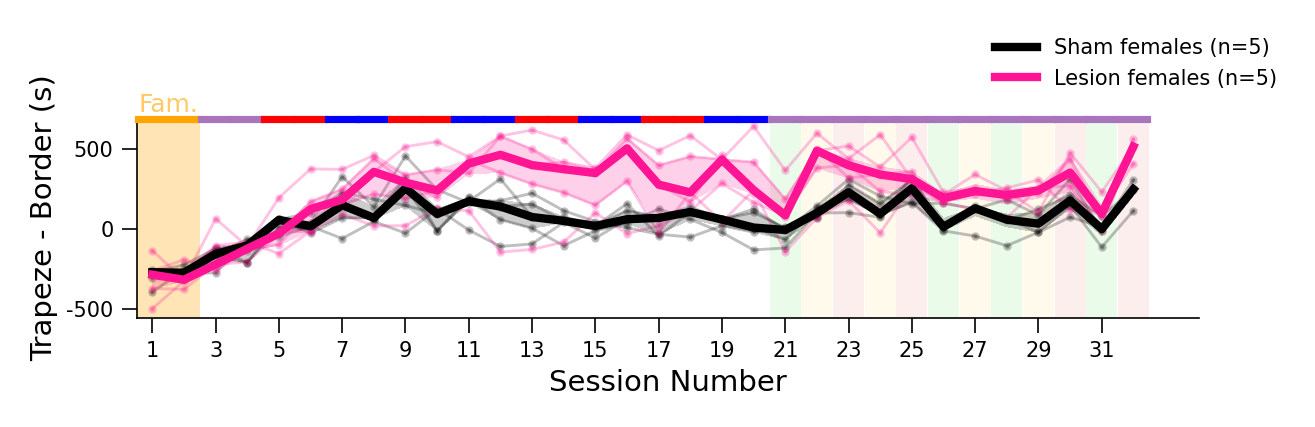

In [13]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(15)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 1, hspace=0.45)

row1 = gs[4].subgridspec(1, 1)
ax_1 = plt.subplot(row1[0, 0])

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_timediff_trapezevsborder,
    ax=ax_1,
    group1_mice=SHAM_ANIMALS,
    group2_mice=LESION_ANIMALS,
    group1_label='Sham females',
    group2_label='Lesion females',
    group1_color='black',
    group2_color='deeppink',
    ylabel='Trapeze - Border (s)',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    show_fam=True,
    legend_loc=(0.8, 1.1)
)

fig.tight_layout()
plt.subplots_adjust(left=0.15)
plt.show()


### Exploitation score

Function(s)

In [14]:
def order_runs(all_epochs):
    ordered_all_runs = []
    ordered_all_runs_frames = []

    for k in all_epochs.keys():
        if k != 'immobility':
            for i in range(len(all_epochs[k])):
                ordered_all_runs.append(all_epochs[k][i])
                ordered_all_runs_frames.append(all_epochs[k][i][0])

    ordered_all_runs_frames = sorted(ordered_all_runs_frames, key=lambda x: x[0])
    ordered_all_runs = sorted(ordered_all_runs, key=lambda x: x[0])

    return ordered_all_runs, ordered_all_runs_frames

def define_visits(all_epochs):
    visits = []
    n = -1

    runs_around_tower = all_epochs['run_around_tower']

    temp_all_epochs = all_epochs.copy()
    temp_all_epochs['run_around_tower'] = runs_around_tower

    ordered_all_runs, ordered_all_runs_frames = order_runs(temp_all_epochs)

    for i, run_around_tower in enumerate(runs_around_tower):
        is_good_turn = run_around_tower[3]['Rewarded']
        max_rewards = run_around_tower[3]['max_rewards']

        ordered_idx = ordered_all_runs_frames.index(run_around_tower[0])

        departure, arrival = (
            [ordered_all_runs[ordered_idx - 1][1][0], ordered_all_runs[ordered_idx - 1][2][0]]
            if ordered_idx != 0 else ['', '']
        )

        previous_run_not_a_turn = (departure != arrival) or len(visits) == 0
        previous_run_started_elsewhere = (
            ordered_all_runs[ordered_idx - 1][1][0] != ordered_all_runs[ordered_idx][1][0]
        ) if ordered_idx != 0 else True

        if previous_run_not_a_turn or previous_run_started_elsewhere:
            n += 1
            visits.append({})

            visits[n]['turns'] = 1
            visits[n]['rewarded_turns'] = int(is_good_turn)
            visits[n]['max_reward'] = max_rewards
            visits[n]['patch'] = run_around_tower[1][0]
            visits[n]['visit_time'] = run_around_tower[4]['epoch_time']
            visits[n]['turns_time'] = [run_around_tower[4]['epoch_time']]
            visits[n]['turns_duration'] = [run_around_tower[4]['epoch_duration']]
        else:
            visits[n]['rewarded_turns'] += int(is_good_turn)
            visits[n]['turns'] += 1
            visits[n]['turns_time'] = visits[n]['turns_time'] + [run_around_tower[4]['epoch_time']]
            visits[n]['turns_duration'] = visits[n]['turns_duration'] + [run_around_tower[4]['epoch_duration']]

    return visits

def define_csv_visits(df):
    n = -1
    visits = []

    for i in range(len(df)):
        previous_transition_in_other_patch = df.currentPatch[i] != df.currentPatch[i - 1] if i > 0 else True
        previous_cumulated_rewards_higher = df.nberOfConsecRewards[i] < df.nberOfConsecRewards[i - 1] if i > 0 else True
        previous_cumulated_rewards_zero = df.nberOfConsecRewards[i - 1] == 0 if i > 0 else True
        left_tower_after_previous_transition = previous_cumulated_rewards_higher and previous_cumulated_rewards_zero

        if previous_transition_in_other_patch or left_tower_after_previous_transition:
            n += 1
            visits.append({})

            visits[n]['transitions'] = 1
            visits[n]['rewarded_transitions'] = int(df.Rewarded[i])
            visits[n]['cumulated_rewards'] = df.nberOfConsecRewards[i]
            visits[n]['max_reward'] = df.maxNberOfConsecRewards[i]
            visits[n]['patch'] = df.currentPatch[i]
            visits[n]['first_transition_time'] = df.time[i]
            visits[n]['transitions_time'] = [df.time[i]]
            visits[n]['transitions_reward_status'] = [df.Rewarded[i]]
        else:
            visits[n]['transitions'] += 1
            visits[n]['rewarded_transitions'] += int(df.Rewarded[i])
            visits[n]['cumulated_rewards'] = df.nberOfConsecRewards[i]
            visits[n]['transitions_time'] = visits[n]['transitions_time'] + [df.time[i]]
            visits[n]['transitions_reward_status'] = visits[n]['transitions_reward_status'] + [df.Rewarded[i]]

    return visits

def find_rewarded_csv_visit(visits):
    return [visit for visit in visits if visit['rewarded_transitions'] > 0]

def check_is_transition_in_pickle_visit(csv_visit, pickle_visit):
    for transition_time in csv_visit['transitions_time']:
        for i in range(len(pickle_visit['turns_time'])):
            turn_start_time = pickle_visit['turns_time'][i]
            turn_end_time = pickle_visit['turns_time'][i] + pickle_visit['turns_duration'][i]

            if turn_start_time <= transition_time <= turn_end_time:
                return True

    return False

def pair_csv_pickle_visits(csv_visits, pickle_visits):
    
    kept_visits = []

    pickle_visits_temp = copy.deepcopy(pickle_visits)
    csv_visits_temp = copy.deepcopy(csv_visits)

    while len(pickle_visits_temp) > 0:
        pickle_visit = pickle_visits_temp[0]

        for i, csv_visit in enumerate(csv_visits_temp):
            is_transition_in_pickle_visit = check_is_transition_in_pickle_visit(csv_visit, pickle_visit)

            if is_transition_in_pickle_visit:
                kept_visits.append(csv_visit)
                pickle_visits_temp.pop(0)
                break

    return kept_visits


Data extraction

In [15]:
mouse_mean_turns_per_rewarded_visit = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:
    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, mouse)

    sessions_to_analyse = sorted([
        name for name in os.listdir(folder_path_mouse_to_analyse)
        if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
        and name.startswith('MOU')
    ])

    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    print(f'Mouse {mouse}. {len(sessions_to_analyse)} sessions')

    for session_index, session_to_analyse in enumerate(sessions_to_analyse):
        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            output_pickle_filename
        )

        turns_csv_path = os.path.join(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            session_to_analyse + '_turnsinfo.csv'
        )

        if not os.path.exists(output_pickle_filepath) or not os.path.exists(turns_csv_path):
            mouse_mean_turns_per_rewarded_visit[mouse].append([session_index + 1, np.nan])
            continue

        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        turns_df = pd.read_csv(turns_csv_path)

        pickle_visits = define_visits(session_data['all_epochs'])
        rewarded_pickle_visits = [v for v in pickle_visits if v['rewarded_turns'] > 0]

        csv_visits = define_csv_visits(turns_df)
        rewarded_csv_visits = find_rewarded_csv_visit(csv_visits)
        paired_rewarded_csv_visits = pair_csv_pickle_visits(rewarded_csv_visits, rewarded_pickle_visits)

        transitions_list = []

        for csv_visit, pickle_visit in zip(paired_rewarded_csv_visits, rewarded_pickle_visits):
            transitions = csv_visit['transitions']

            if csv_visit['transitions_time'][-1] > (
                pickle_visit['turns_time'][-1] + pickle_visit['turns_duration'][-1]
            ):
                transitions -= 1

            transitions_list.append(transitions)

        mean_turns_per_rewarded_visit = np.nanmean(transitions_list) if len(transitions_list) > 0 else np.nan

        if session_index >= 2:
            mouse_mean_turns_per_rewarded_visit[mouse].append([session_index + 1, mean_turns_per_rewarded_visit])
        else:
            mouse_mean_turns_per_rewarded_visit[mouse].append([session_index + 1, np.nan])


Mouse MOUB6JRj753. 32 sessions
Mouse MOUB6JRj755. 32 sessions
Mouse MOUB6JRj756. 32 sessions
Mouse MOU5289. 32 sessions
Mouse MOU5291. 32 sessions
Mouse MOU5413. 32 sessions
Mouse MOU5415. 32 sessions
Mouse MOU5471. 31 sessions
Mouse MOU5496. 25 sessions
Mouse MOU5498. 25 sessions


/tmp/ipykernel_8476/538453482.py:43: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


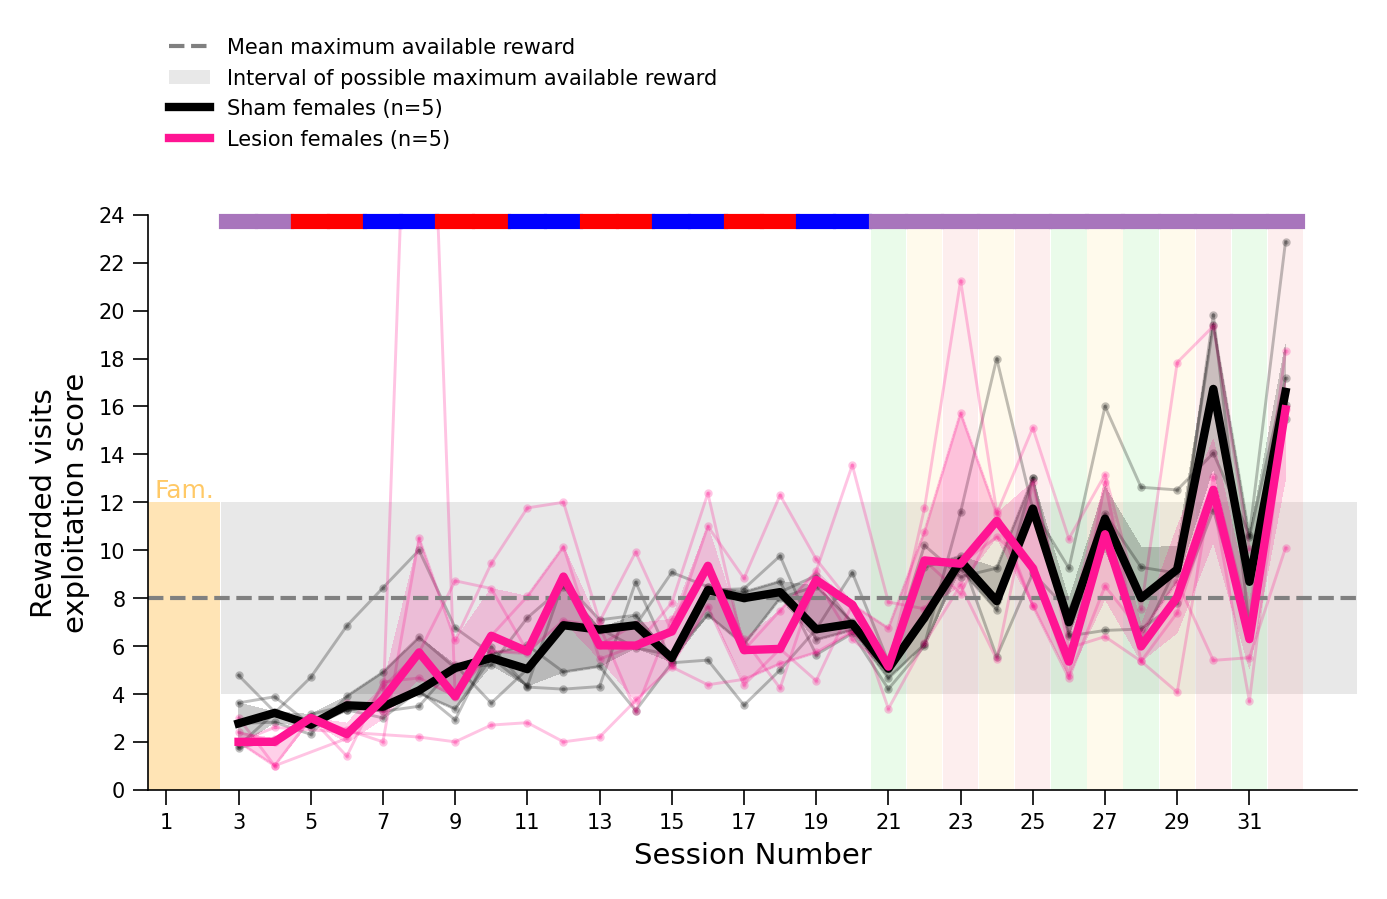

In [16]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(8)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

ax.axhline(
    8,
    linestyle='--',
    color='gray',
    linewidth=1,
    label='Mean maximum available reward'
)

ax.axhspan(
    4, 12,
    xmin=0.06,
    color='lightgray',
    alpha=0.5,
    linewidth=0,
    zorder=-np.inf,
    label='Interval of possible maximum available reward'
)

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_mean_turns_per_rewarded_visit,
    ax=ax,
    group1_mice=SHAM_ANIMALS,
    group2_mice=LESION_ANIMALS,
    group1_label='Sham females',
    group2_label='Lesion females',
    group1_color='black',
    group2_color='deeppink',
    ylabel='Rewarded visits\nexploitation score',
    show_xlabel=True,
    tick_interval=2,
    index_offset=0,
    xlim=[0.5, None],
    ylim=[0, 12],
    show_fam=True,
    legend_loc=(0.01, 1.1)
)

ax.set_yticks(range(0, 25, 2))

fig.tight_layout()
plt.show()

### Fréchet distance
Function(s)

In [17]:
def towers_coordinates_as_dictionnary(towers_coordinates_cm):
    """
    Convertit les coordonnées des tours en dictionnaire structuré
    avec les coins explicitement nommés.
    """

    towers_coordinates_as_dict = {}
    corner_names = ['NW', 'NE', 'SE', 'SW']

    for tower, coordinates in towers_coordinates_cm.items():
        towers_coordinates_as_dict[tower] = {
            corner_names[i]: coord for i, coord in enumerate(coordinates)
        }

    return towers_coordinates_as_dict

def get_tower_and_corner(run_around_tower):
    """
    Détermine le nom de la tour et le coin concerné à partir
    des infos de départ/arrivée du QT.
    """

    tower_name = run_around_tower[1][0]
    start_trapeze = run_around_tower[1][1]
    end_trapeze = run_around_tower[2][1]

    if start_trapeze == 'W' and end_trapeze == 'S':
        corner = 'SW'
    elif start_trapeze == 'S' and end_trapeze == 'E':
        corner = 'SE'
    elif start_trapeze == 'E' and end_trapeze == 'N':
        corner = 'NE'
    elif start_trapeze == 'N' and end_trapeze == 'W':
        corner = 'NW'
    elif start_trapeze == 'W' and end_trapeze == 'N':
        corner = 'NW'
    elif start_trapeze == 'N' and end_trapeze == 'E':
        corner = 'NE'
    elif start_trapeze == 'E' and end_trapeze == 'S':
        corner = 'SE'
    elif start_trapeze == 'S' and end_trapeze == 'W':
        corner = 'SW'
    else:
        corner = None

    return tower_name, corner

def rotate_sw_trajectory_90_ccw(trajectory):
    """
    Rotation 90° sens anti-horaire.
    """
    rotation_matrix = np.array([[0, -1], [1, 0]])
    return rotation_matrix @ trajectory

def rotate_nw_trajectory_180_ccw(trajectory):
    """
    Rotation 180° sens anti-horaire.
    """
    return -trajectory

def rotate_ne_trajectory_270_ccw(trajectory):
    """
    Rotation 270° sens anti-horaire.
    """
    rotation_matrix = np.array([[0, 1], [-1, 0]])
    return rotation_matrix @ trajectory

def align_cw_ccw_trajectory(trajectory, direction, flip_axis='x'):
    """
    Align CCW quarter-turns onto the CW reference frame.
    
    Parameters
    ----------
    trajectory : np.ndarray
        2 x N array
    direction : str
        'CW' or 'CCW'
    flip_axis : str
        'x' or 'y'. Axis used to mirror CCW trajectories.
    
    Returns
    -------
    np.ndarray
        Aligned trajectory
    """
    aligned_trajectory = trajectory.copy()

    if direction == 'CCW':
        if flip_axis == 'x':
            aligned_trajectory[0, :] = -aligned_trajectory[0, :]
        elif flip_axis == 'y':
            aligned_trajectory[1, :] = -aligned_trajectory[1, :]
        else:
            raise ValueError("flip_axis must be 'x' or 'y'")

    return aligned_trajectory

def compute_frechet_distances(runs_list):
    """
    Calcule la distance de Fréchet pour toutes les paires de trajectoires.
    Les trajectoires doivent être au format (2, N).
    Retourne la liste des distances.
    """

    frechet_distances_list = []

    for i in range(len(runs_list)):
        traj_points_a = np.transpose(runs_list[i])

        for j in range(i + 1, len(runs_list)):
            traj_points_b = np.transpose(runs_list[j])
            frechet_distance = sm.frechet_dist(traj_points_a, traj_points_b)
            frechet_distances_list.append(frechet_distance)

    return frechet_distances_list

def align_qt_trajectory(this_trajectory, tower_name, corner, direction,
                        towers_coordinates_as_dict,
                        align_direction=False, flip_axis='x'):
    """
    Align a QT trajectory:
    1) translate to tower corner
    2) rotate depending on corner
    3) optionally mirror CCW onto CW
    
    Parameters
    ----------
    this_trajectory : np.ndarray
        2 x N trajectory
    tower_name : str
    corner : str
    direction : str
        'CW' or 'CCW'
    towers_coordinates_as_dict : dict
    align_direction : bool
        If True, CCW trajectories are mirrored onto CW reference frame
    flip_axis : str
        'x' or 'y'
    
    Returns
    -------
    np.ndarray
        aligned trajectory
    """
    aligned_trajectory = this_trajectory.copy()

    this_corner_coordinates = towers_coordinates_as_dict[tower_name][corner]

    # Translation
    aligned_trajectory[0, :] -= this_corner_coordinates[0]
    aligned_trajectory[1, :] -= this_corner_coordinates[1]

    # Rotation depending on corner
    if corner == 'SW':
        aligned_trajectory = rotate_sw_trajectory_90_ccw(aligned_trajectory)
    elif corner == 'NW':
        aligned_trajectory = rotate_nw_trajectory_180_ccw(aligned_trajectory)
    elif corner == 'NE':
        aligned_trajectory = rotate_ne_trajectory_270_ccw(aligned_trajectory)
    # if corner == 'SE': do nothing

    # Optional CW/CCW alignment
    if align_direction:
        aligned_trajectory = align_cw_ccw_trajectory(
            aligned_trajectory,
            direction=direction,
            flip_axis=flip_axis
        )

    return aligned_trajectory

def compute_session_frechet(trajectories, minimum_number_of_qts=5):
    if len(trajectories) >= minimum_number_of_qts:
        return np.nanmedian(compute_frechet_distances(trajectories))
    return np.nan

def compute_frechet_for_one_session(folder_path_mouse_to_process, session_to_process, minimum_number_of_qts=5):
    
    output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(
        folder_path_mouse_to_process,
        session_to_process,
        output_pickle_filename
    )

    if not os.path.exists(output_pickle_filepath):
        return {
            "rewarded_frechet": np.nan,
            "unrewarded_frechet": np.nan,
            "cw_frechet": np.nan,
            "ccw_frechet": np.nan,
            "cw_rew_frechet": np.nan,
            "ccw_rew_frechet": np.nan,
            "cw_unrew_frechet": np.nan,
            "ccw_unrew_frechet": np.nan,
        }

    with open(output_pickle_filepath, "rb") as file:
        session_data = pickle.load(file)

    runs_around_tower = filter_qts(copy.deepcopy(session_data["all_epochs"]["run_around_tower"]))
    positions = np.array(session_data["positions"])

    towers_coordinates_cm = session_data["towers_coordinates_cm"]
    towers_coordinates_as_dict = towers_coordinates_as_dictionnary(towers_coordinates_cm)

    rewarded_trajectories = []
    unrewarded_trajectories = []
    cw_trajectories = []
    ccw_trajectories = []
    cw_rewarded_trajectories = []
    ccw_rewarded_trajectories = []
    cw_unrewarded_trajectories = []
    ccw_unrewarded_trajectories = []

    for run_around_tower in runs_around_tower:

        if run_around_tower[3]["num_trapezeswitch"] != 1:
            continue

        rewarded = run_around_tower[3]["Rewarded"]
        direction = run_around_tower[3]["direction"]

        if direction not in ["CW", "CCW"]:
            continue

        tower_name, corner = get_tower_and_corner(run_around_tower)

        if tower_name not in towers_coordinates_as_dict:
            continue

        if corner not in towers_coordinates_as_dict[tower_name]:
            continue

        start_idx, end_idx = run_around_tower[0]
        this_trajectory = positions[:, start_idx:end_idx].copy()

        aligned_for_reward = align_qt_trajectory(
            this_trajectory=this_trajectory,
            tower_name=tower_name,
            corner=corner,
            direction=direction,
            towers_coordinates_as_dict=towers_coordinates_as_dict,
            align_direction=True,
            flip_axis="x"
        )

        aligned_for_direction = align_qt_trajectory(
            this_trajectory=this_trajectory,
            tower_name=tower_name,
            corner=corner,
            direction=direction,
            towers_coordinates_as_dict=towers_coordinates_as_dict,
            align_direction=False
        )

        if rewarded:
            rewarded_trajectories.append(aligned_for_reward)
        else:
            unrewarded_trajectories.append(aligned_for_reward)

        if direction == "CW":
            cw_trajectories.append(aligned_for_direction)
            if rewarded:
                cw_rewarded_trajectories.append(aligned_for_direction)
            else:
                cw_unrewarded_trajectories.append(aligned_for_direction)

        elif direction == "CCW":
            ccw_trajectories.append(aligned_for_direction)
            if rewarded:
                ccw_rewarded_trajectories.append(aligned_for_direction)
            else:
                ccw_unrewarded_trajectories.append(aligned_for_direction)

    frechet_results = {
        "rewarded_frechet": compute_session_frechet(rewarded_trajectories, minimum_number_of_qts),
        "unrewarded_frechet": compute_session_frechet(unrewarded_trajectories, minimum_number_of_qts),
        "cw_frechet": compute_session_frechet(cw_trajectories, minimum_number_of_qts),
        "ccw_frechet": compute_session_frechet(ccw_trajectories, minimum_number_of_qts),
        "cw_rew_frechet": compute_session_frechet(cw_rewarded_trajectories, minimum_number_of_qts),
        "ccw_rew_frechet": compute_session_frechet(ccw_rewarded_trajectories, minimum_number_of_qts),
        "cw_unrew_frechet": compute_session_frechet(cw_unrewarded_trajectories, minimum_number_of_qts),
        "ccw_unrew_frechet": compute_session_frechet(ccw_unrewarded_trajectories, minimum_number_of_qts),
    }

    return frechet_results


Data extraction

In [18]:
FRECHET_PICKLE_NAMES = {
    "ccw_unrew_frechet": "ccw_unrew_frechet.pickle",
    "cw_unrew_frechet": "cw_unrew_frechet.pickle",
    "ccw_rew_frechet": "ccw_rew_frechet.pickle",
    "cw_rew_frechet": "cw_rew_frechet.pickle",
    "ccw_frechet": "ccw_frechet.pickle",
    "cw_frechet": "cw_frechet.pickle",
    "unrewarded_frechet": "unrewarded_frechet.pickle",
    "rewarded_frechet": "rewarded_frechet.pickle",
}

In [19]:
rewarded_turns_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
unrewarded_turns_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
cw_turns_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
ccw_turns_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
cw_rewarded_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
ccw_rewarded_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
cw_unrewarded_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}
ccw_unrewarded_frechet_distances_per_session = {mouse: [] for mouse in mice_to_analyse}

allsessionnumber = list(range(first_and_last_session_indexes[0] + 1,
                              first_and_last_session_indexes[1] + 1))

minimum_number_of_qts = 5

for mouse in mice_to_analyse:

    print(f"Computing/loading Fréchet distances for {mouse}")

    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    sessions_to_process = sorted([
        name for name in os.listdir(folder_path_mouse_to_process)
        if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
        and name.startswith("MOU")
    ])

    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    for session_index, session_to_process in enumerate(sessions_to_process):

        pickle_jar_path = get_pickle_jar_path(folder_path_mouse_to_process, session_to_process)

        if frechet_pickles_exist(pickle_jar_path, FRECHET_PICKLE_NAMES):
            frechet_results = load_frechet_pickles(pickle_jar_path, FRECHET_PICKLE_NAMES)
            print(f"  Session {session_to_process}: pickles already exist, loading.")
        else:
            print(f"  Session {session_to_process}: pickle does not exist. Processing.")
            frechet_results = compute_frechet_for_one_session(
                folder_path_mouse_to_process,
                session_to_process,
                minimum_number_of_qts=minimum_number_of_qts
            )
            save_frechet_pickles(pickle_jar_path, frechet_results, FRECHET_PICKLE_NAMES)
            # print(f"Session {session_to_process}: processed and saved.")

        session_number = allsessionnumber[session_index]

        rewarded_turns_frechet_distances_per_session[mouse].append([session_number, frechet_results["rewarded_frechet"]])
        unrewarded_turns_frechet_distances_per_session[mouse].append([session_number, frechet_results["unrewarded_frechet"]])
        cw_turns_frechet_distances_per_session[mouse].append([session_number, frechet_results["cw_frechet"]])
        ccw_turns_frechet_distances_per_session[mouse].append([session_number, frechet_results["ccw_frechet"]])
        cw_rewarded_frechet_distances_per_session[mouse].append([session_number, frechet_results["cw_rew_frechet"]])
        ccw_rewarded_frechet_distances_per_session[mouse].append([session_number, frechet_results["ccw_rew_frechet"]])
        cw_unrewarded_frechet_distances_per_session[mouse].append([session_number, frechet_results["cw_unrew_frechet"]])
        ccw_unrewarded_frechet_distances_per_session[mouse].append([session_number, frechet_results["ccw_unrew_frechet"]])

    print(f"All {mouse} sessions processed and saved.")


Computing/loading Fréchet distances for MOUB6JRj753
  Session MOUB6JRj753_20260109-1001: pickles already exist, loading.
  Session MOUB6JRj753_20260109-1528: pickles already exist, loading.
  Session MOUB6JRj753_20260113-0952: pickles already exist, loading.
  Session MOUB6JRj753_20260113-1431: pickles already exist, loading.
  Session MOUB6JRj753_20260114-1001: pickles already exist, loading.
  Session MOUB6JRj753_20260114-1510: pickles already exist, loading.
  Session MOUB6JRj753_20260115-0953: pickles already exist, loading.
  Session MOUB6JRj753_20260115-1448: pickles already exist, loading.
  Session MOUB6JRj753_20260116-0948: pickles already exist, loading.
  Session MOUB6JRj753_20260116-1449: pickles already exist, loading.
  Session MOUB6JRj753_20260117-1008: pickles already exist, loading.
  Session MOUB6JRj753_20260117-1500: pickles already exist, loading.
  Session MOUB6JRj753_20260118-1012: pickles already exist, loading.
  Session MOUB6JRj753_20260118-1440: pickles alread

Plot

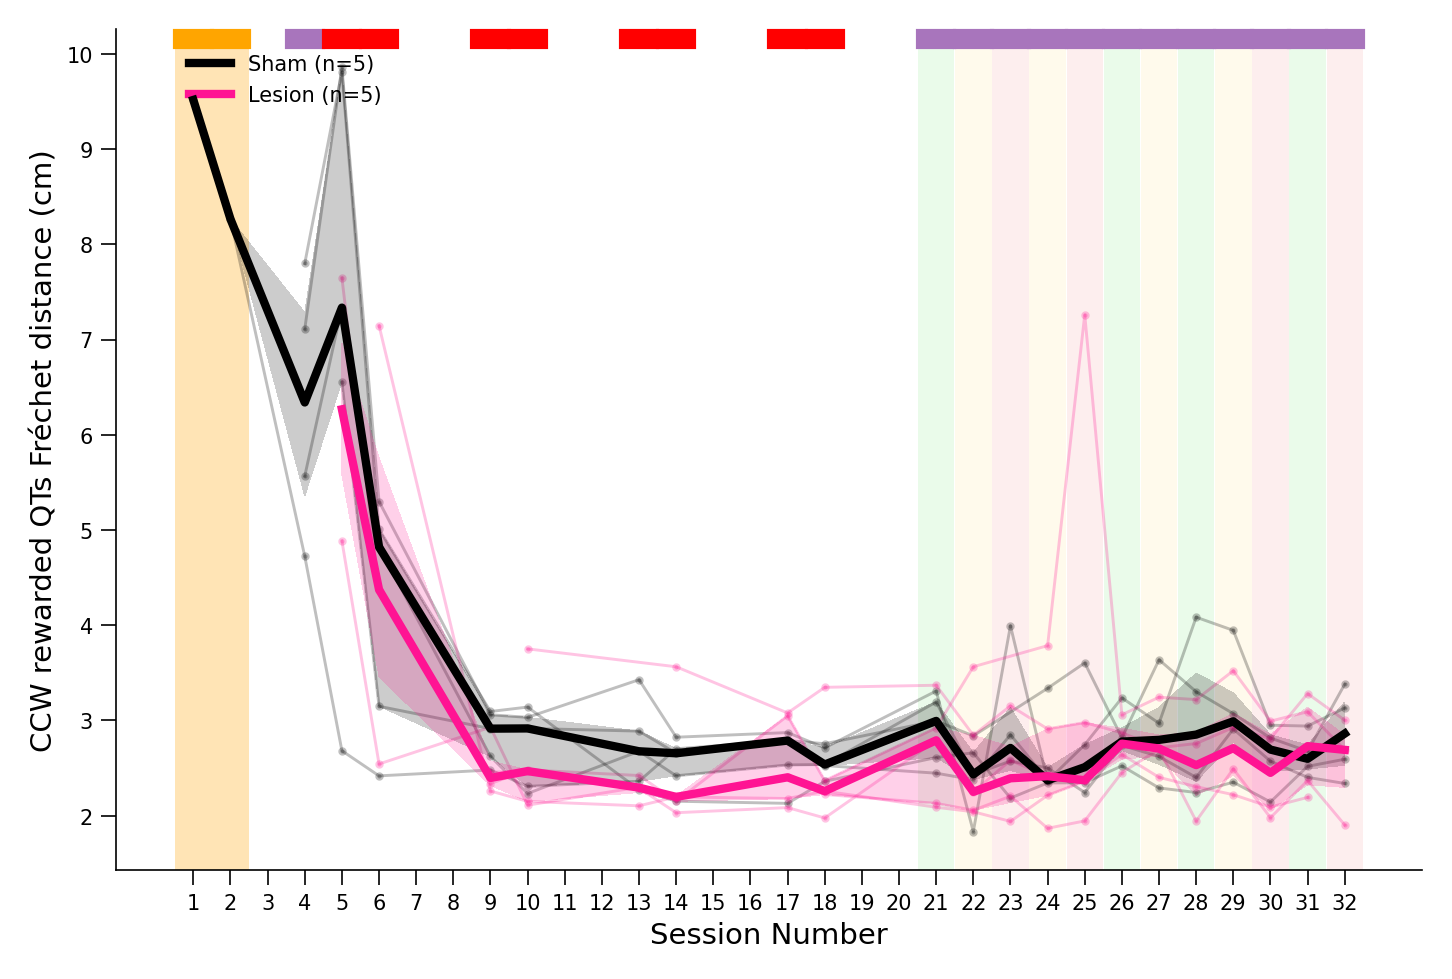

In [20]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(8)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=ccw_rewarded_frechet_distances_per_session,
    ax=ax,
    group1_mice=SHAM_ANIMALS,
    group2_mice=LESION_ANIMALS,
    ylabel='CCW rewarded QTs Fréchet distance (cm)'
)


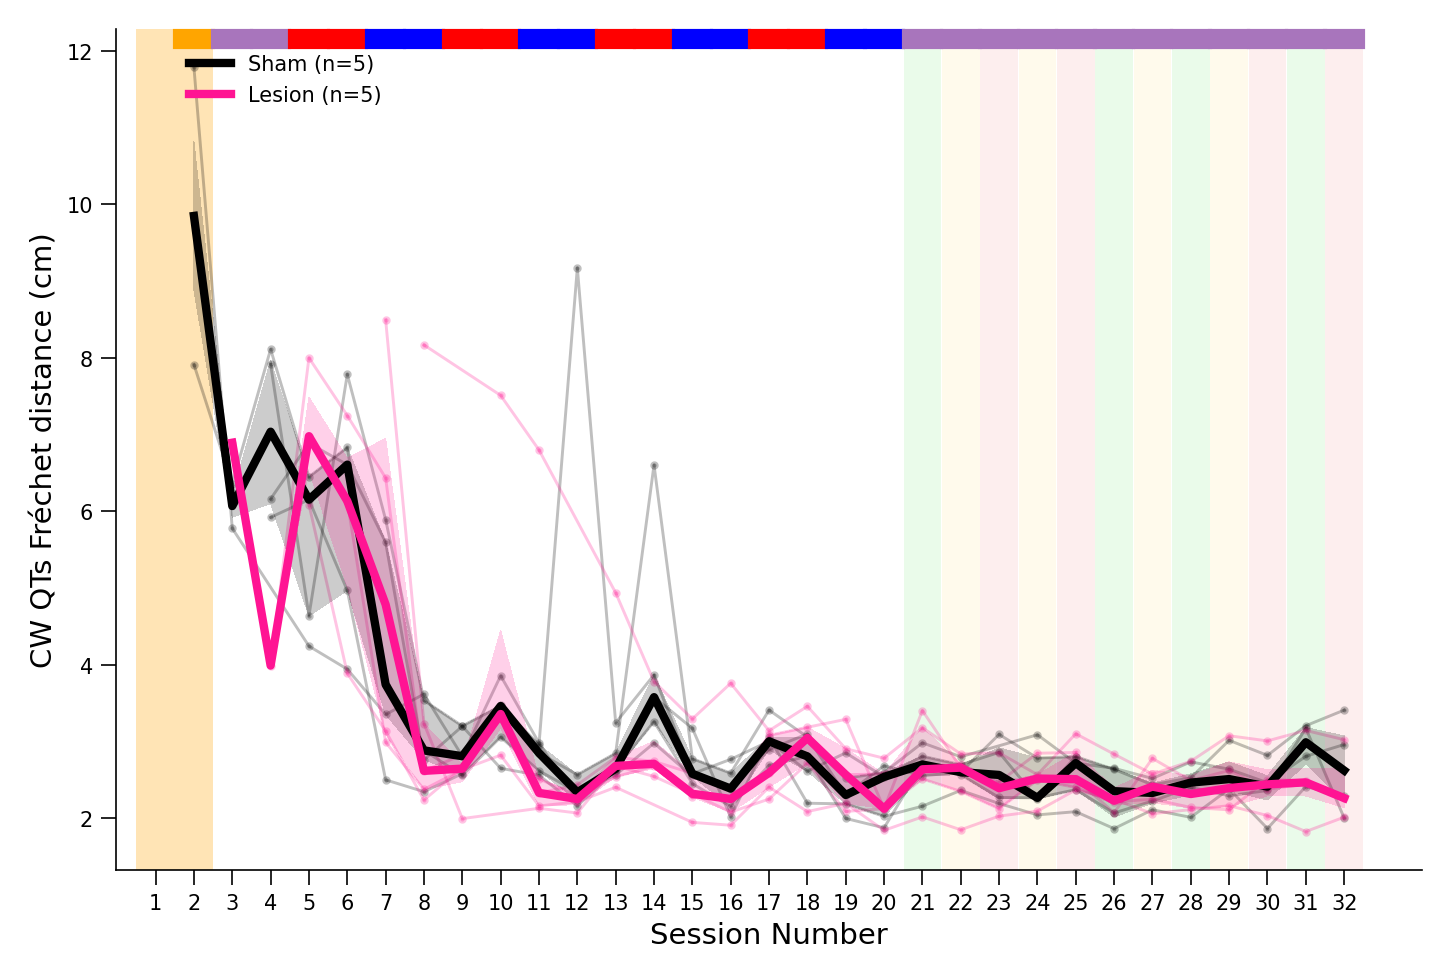

In [21]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(8)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=cw_turns_frechet_distances_per_session,
    ax=ax,
    group1_mice=SHAM_ANIMALS,
    group2_mice=LESION_ANIMALS,
    ylabel='CW QTs Fréchet distance (cm)'
)


### QTs speed
Data extraction

In [22]:
mouse_median_qt_maxspeed_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_median_qt_meanspeed_persession = {mouse: [] for mouse in mice_to_analyse}

for mouse in mice_to_analyse:
    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder, mouse)

    sessions_to_analyse = sorted([
        name for name in os.listdir(folder_path_mouse_to_analyse)
        if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
        and name.startswith('MOU')
    ])

    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    print(f'Mouse {mouse}. {len(sessions_to_analyse)} sessions')

    for session_index, session_to_analyse in enumerate(sessions_to_analyse):
        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(
            folder_path_mouse_to_analyse,
            session_to_analyse,
            output_pickle_filename
        )

        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file missing for session {session_to_analyse}, skipping...')
            mouse_median_qt_maxspeed_persession[mouse].append([session_index + 1, np.nan])
            mouse_median_qt_meanspeed_persession[mouse].append([session_index + 1, np.nan])
            continue

        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Tous les QTs filtrés, sans séparer CW / CCW
        qts = filter_qts(session_data["all_epochs"]["run_around_tower"])

        if len(qts) == 0:
            median_qt_maxspeed = np.nan
            median_qt_meanspeed = np.nan

        else:
            qt_maxspeeds = [qt[4]["epoch_maxspeed"] for qt in qts]
            qt_meanspeeds = [qt[4]["epoch_meanspeed"] for qt in qts]

            median_qt_maxspeed = np.nanmedian(qt_maxspeeds)
            median_qt_meanspeed = np.nanmedian(qt_meanspeeds)

        mouse_median_qt_maxspeed_persession[mouse].append([session_index + 1, median_qt_maxspeed])
        mouse_median_qt_meanspeed_persession[mouse].append([session_index + 1, median_qt_meanspeed])    


Mouse MOUB6JRj753. 32 sessions
Mouse MOUB6JRj755. 32 sessions
Mouse MOUB6JRj756. 32 sessions
Mouse MOU5289. 32 sessions
Mouse MOU5291. 32 sessions
Mouse MOU5413. 32 sessions
Mouse MOU5415. 32 sessions
Mouse MOU5471. 31 sessions
Mouse MOU5496. 25 sessions
Mouse MOU5498. 25 sessions


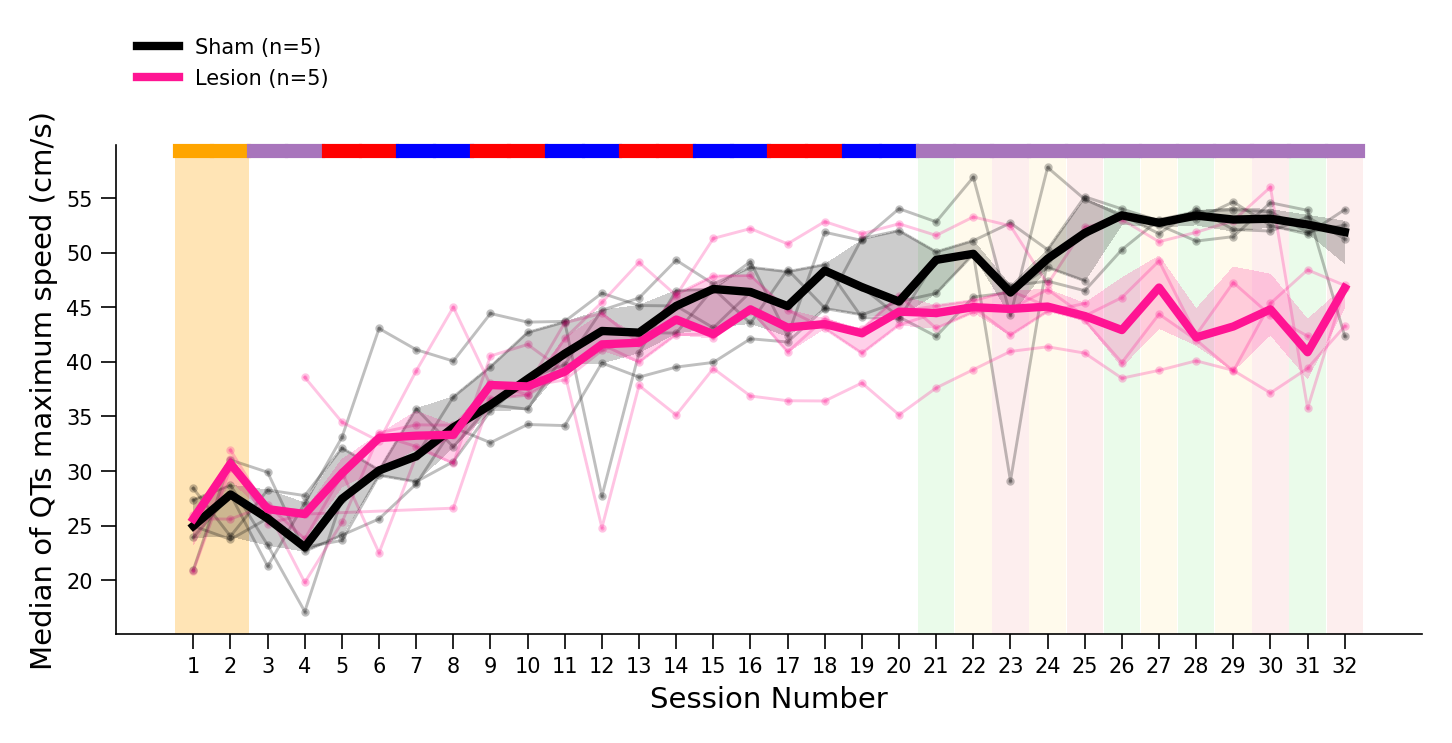

In [23]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(6)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_median_qt_maxspeed_persession,
    ax=ax,
    group1_mice=SHAM_ANIMALS,
    group2_mice=LESION_ANIMALS,
    ylabel='Median of QTs maximum speed (cm/s)',
    legend_loc=(0.01, 1.1)
)


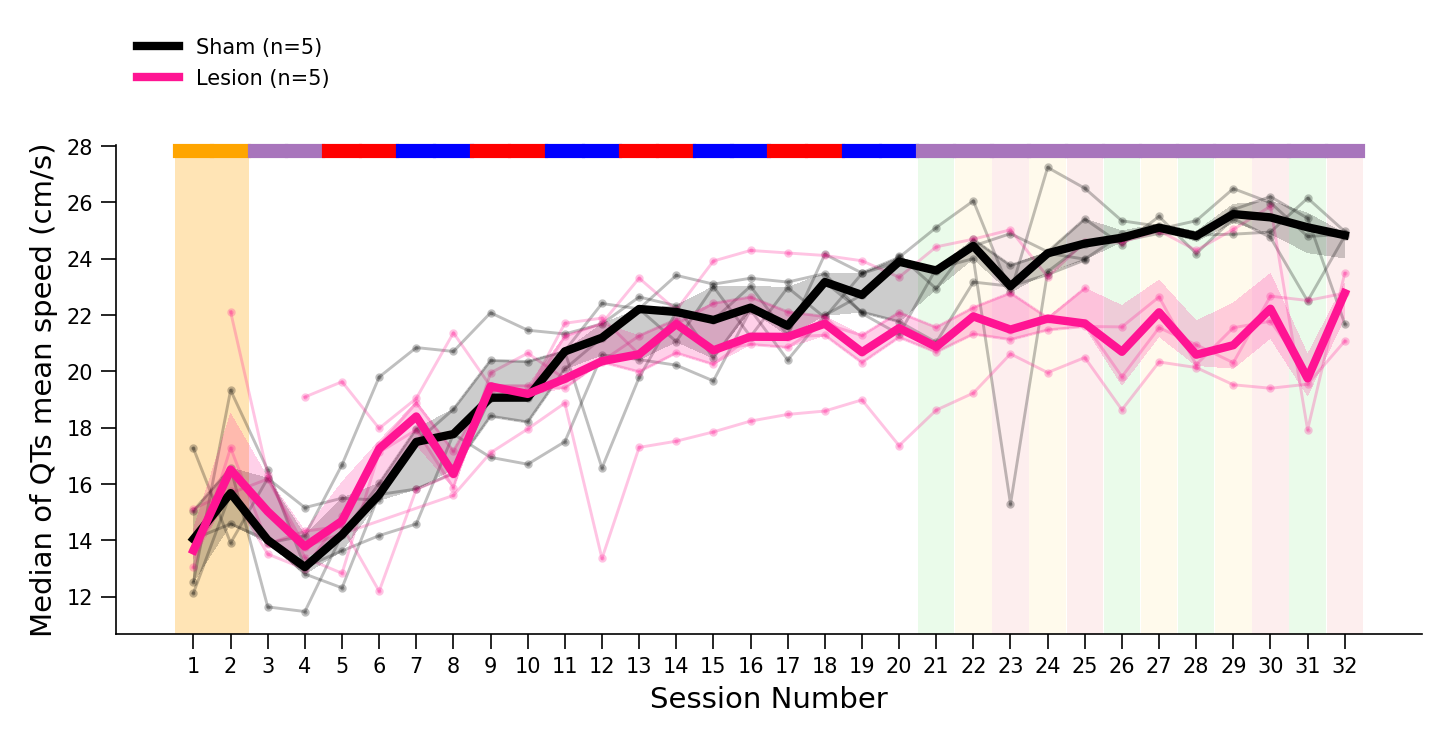

In [24]:
fig = plt.figure(figsize=(cm2inch(12), cm2inch(6)), dpi=300, facecolor='w')
ax = fig.add_subplot(111)

plot_learning_curves_two_groups(
    mouse_metric_persession=mouse_median_qt_meanspeed_persession,
    ax=ax,
    group1_mice=SHAM_ANIMALS,
    group2_mice=LESION_ANIMALS,
    ylabel='Median of QTs mean speed (cm/s)',
    legend_loc=(0.01, 1.1)
)
